In [1]:
import importlib, subprocess, sys
REQUIRED = {
    'diffusers': 'diffusers>=0.27.0',
    'transformers': 'transformers>=4.41.0',
    'accelerate': 'accelerate>=0.30.0',
    'peft': 'peft>=0.11.0',
    'bitsandbytes': 'bitsandbytes',
    'safetensors': 'safetensors',
    'huggingface_hub': 'huggingface-hub',
}
missing = [pkg for mod, pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    print('installing:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])

In [2]:
import os, json, glob, shutil, time, random, math, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

torch.manual_seed(0); np.random.seed(0); random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('PyTorch:', torch.__version__)
print('CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1), 'GB')

PyTorch: 2.4.1+cu121
CUDA: True
GPU: NVIDIA GeForce RTX 2080 SUPER
VRAM: 7.6 GB


In [3]:
LAB = Path(os.getcwd()).resolve()
if LAB.name != 'lab-8':
    cand = LAB / 'lab-8'
    if cand.exists():
        LAB = cand.resolve()
DATA = LAB / 'data'
ME_DIR = DATA / 'me'
LORA_DIR = LAB / 'runs' / 'lora_sd15'
SAMPLES_DIR = LAB / 'samples'
RESULTS_PATH = LAB / 'results.json'

for p in [DATA, ME_DIR, LORA_DIR, SAMPLES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

BASE_MODEL = 'runwayml/stable-diffusion-v1-5'
INSTANCE_TOKEN = 'sks'
GENDER = 'man'
INSTANCE_PROMPT = f'a photo of {INSTANCE_TOKEN} {GENDER}'

RESOLUTION = 512
LORA_RANK = 16
LR = 1e-4
MAX_TRAIN_STEPS = 1200
GRAD_ACCUM = 2
BATCH = 1
SAVE_EVERY = 400

INFERENCE_STEPS = 30
GUIDANCE = 7.5
SEED = 42

print('LAB:', LAB)
print('device:', device)
print('instance prompt:', INSTANCE_PROMPT)

LAB: /mnt/data/itmo-cv/lab-8
device: cuda
instance prompt: a photo of sks man


## 1. Референсные фото

20 reference photos in /mnt/data/itmo-cv/lab-8/data/me


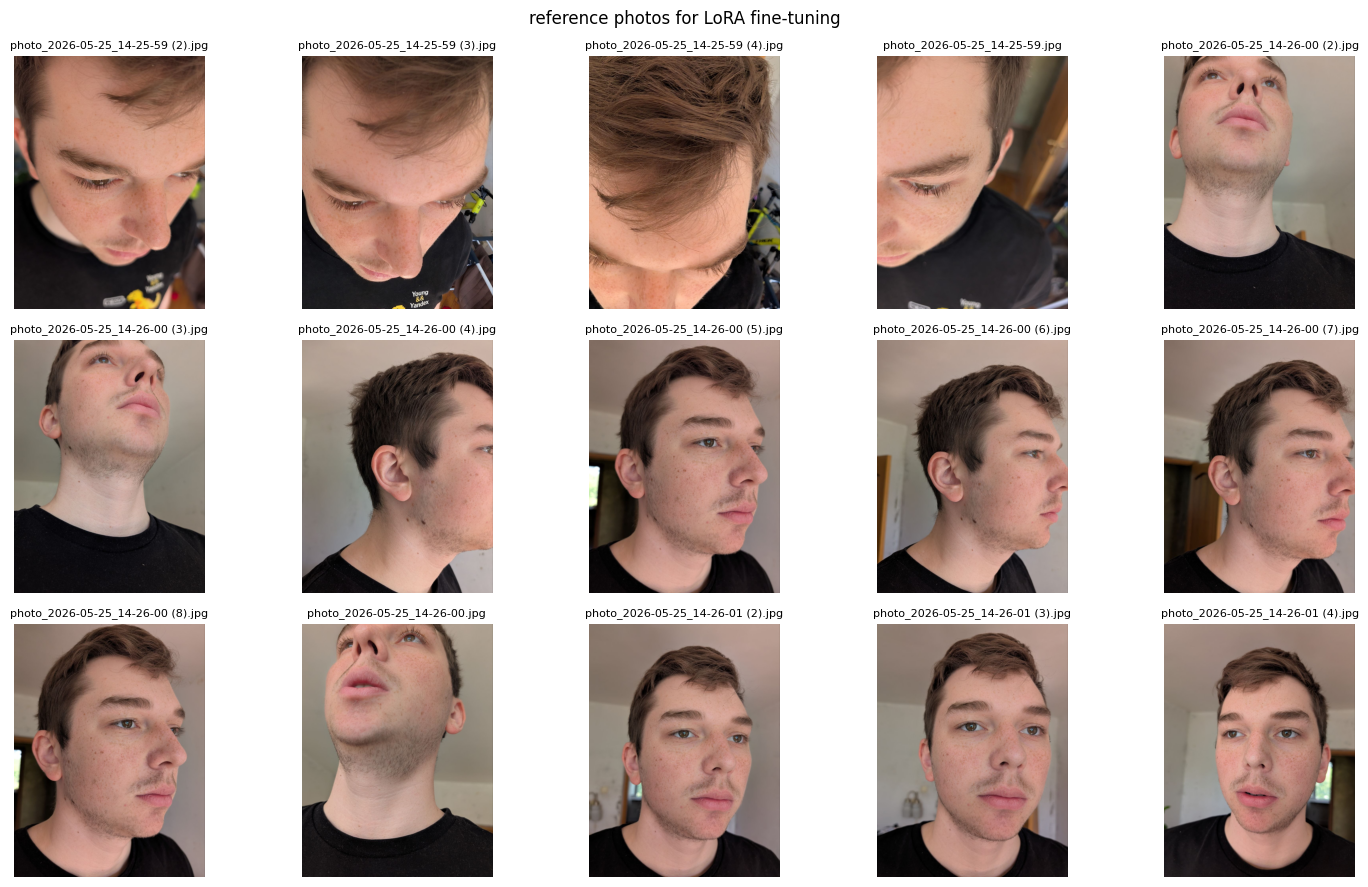

In [4]:
exts = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG', '*.heic', '*.HEIC']
me_imgs = sorted(sum([list(ME_DIR.glob(e)) for e in exts], []))
print(f'{len(me_imgs)} reference photos in {ME_DIR}')
if len(me_imgs) < 5:
    raise SystemExit(f'нужно минимум 5 (а лучше 12-15) фото в {ME_DIR}')

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for ax, p in zip(axes.flat, me_imgs[:15]):
    ax.imshow(Image.open(p).convert('RGB'))
    ax.set_title(p.name, fontsize=8)
    ax.axis('off')
for ax in axes.flat[len(me_imgs):]:
    ax.axis('off')
plt.suptitle('reference photos for LoRA fine-tuning')
plt.tight_layout(); plt.show()

## 2. Загрузка SD 1.5 и подготовка LoRA

In [5]:
from diffusers import StableDiffusionPipeline, DDPMScheduler, AutoencoderKL, UNet2DConditionModel
from transformers import CLIPTextModel, CLIPTokenizer
from peft import LoraConfig, get_peft_model
import bitsandbytes as bnb

tokenizer = CLIPTokenizer.from_pretrained(BASE_MODEL, subfolder='tokenizer')
text_encoder = CLIPTextModel.from_pretrained(BASE_MODEL, subfolder='text_encoder', torch_dtype=torch.float16).to(device)
vae = AutoencoderKL.from_pretrained(BASE_MODEL, subfolder='vae', torch_dtype=torch.float16).to(device)
unet = UNet2DConditionModel.from_pretrained(BASE_MODEL, subfolder='unet', torch_dtype=torch.float32).to(device)
noise_scheduler = DDPMScheduler.from_pretrained(BASE_MODEL, subfolder='scheduler')

for p in text_encoder.parameters(): p.requires_grad_(False)
for p in vae.parameters(): p.requires_grad_(False)
for p in unet.parameters(): p.requires_grad_(False)

unet.enable_gradient_checkpointing()

lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_RANK,
    target_modules=['to_q', 'to_k', 'to_v', 'to_out.0'],
    lora_dropout=0.0,
    bias='none',
)
unet = get_peft_model(unet, lora_config)
unet.print_trainable_parameters()

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

trainable params: 3,188,736 || all params: 862,709,700 || trainable%: 0.3696


## 3. Dataset из ваших фото

In [6]:
class InstanceDataset(Dataset):
    def __init__(self, image_paths, prompt, tokenizer, resolution=512):
        self.paths = image_paths
        self.prompt = prompt
        self.tokenizer = tokenizer
        self.tf = transforms.Compose([
            transforms.Resize(resolution, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.CenterCrop(resolution),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3),
        ])
        self.input_ids = tokenizer(prompt, padding='max_length', max_length=tokenizer.model_max_length, truncation=True, return_tensors='pt').input_ids[0]
    def __len__(self):
        return len(self.paths) * 100
    def __getitem__(self, i):
        p = self.paths[i % len(self.paths)]
        img = Image.open(p).convert('RGB')
        return {'pixel_values': self.tf(img), 'input_ids': self.input_ids}


train_ds = InstanceDataset(me_imgs, INSTANCE_PROMPT, tokenizer, RESOLUTION)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=True)
print('dataset:', len(train_ds), 'samples (with repeat), batch=', BATCH)

dataset: 2000 samples (with repeat), batch= 1


## 4. Тренировка LoRA

In [7]:
lora_state_path = LORA_DIR / 'lora_weights.safetensors'
history_path = LORA_DIR / 'history.csv'

if lora_state_path.exists():
    print(f'[skip] LoRA already trained: {lora_state_path}')
    history = pd.read_csv(history_path).values.tolist() if history_path.exists() else []
else:
    trainable_params = [p for p in unet.parameters() if p.requires_grad]
    optimizer = bnb.optim.AdamW8bit(trainable_params, lr=LR, betas=(0.9, 0.999), weight_decay=1e-2, eps=1e-8)
    history = []
    step = 0
    t0 = time.time()
    pbar = tqdm(total=MAX_TRAIN_STEPS, desc='lora train')
    accum_loss = 0.0
    while step < MAX_TRAIN_STEPS:
        for batch in train_loader:
            pixel_values = batch['pixel_values'].to(device, dtype=torch.float16)
            input_ids = batch['input_ids'].to(device)

            with torch.no_grad():
                latents = vae.encode(pixel_values).latent_dist.sample() * vae.config.scaling_factor
                encoder_hidden_states = text_encoder(input_ids.unsqueeze(0) if input_ids.dim() == 1 else input_ids)[0]

            noise = torch.randn_like(latents)
            bs = latents.size(0)
            timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bs,), device=device).long()
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

            with torch.autocast(device_type='cuda', dtype=torch.float16):
                model_pred = unet(noisy_latents.float(), timesteps, encoder_hidden_states.float()).sample
                loss = F.mse_loss(model_pred.float(), noise.float())
            (loss / GRAD_ACCUM).backward()
            accum_loss += loss.item()

            if (step + 1) % GRAD_ACCUM == 0:
                optimizer.step()
                optimizer.zero_grad()

            step += 1
            if step % 20 == 0:
                avg = accum_loss / 20
                history.append([step, avg])
                pbar.set_postfix(loss=f'{avg:.4f}')
                accum_loss = 0.0
            pbar.update(1)
            if step % SAVE_EVERY == 0 or step >= MAX_TRAIN_STEPS:
                pd.DataFrame(history, columns=['step', 'loss']).to_csv(history_path, index=False)
            if step >= MAX_TRAIN_STEPS:
                break
    pbar.close()

    from safetensors.torch import save_file
    lora_sd = {k: v.detach().cpu().contiguous() for k, v in unet.state_dict().items() if 'lora_' in k}
    save_file(lora_sd, str(lora_state_path))
    pd.DataFrame(history, columns=['step', 'loss']).to_csv(history_path, index=False)
    print(f'LoRA trained in {(time.time()-t0)/60:.1f} min, weights: {lora_state_path}')

lora train:   0%|          | 0/1200 [00:00<?, ?it/s]

lora train:   0%|          | 1/1200 [00:01<28:22,  1.42s/it]

lora train:   0%|          | 2/1200 [00:01<14:48,  1.35it/s]

lora train:   0%|          | 3/1200 [00:01<09:59,  2.00it/s]

lora train:   0%|          | 4/1200 [00:02<07:51,  2.54it/s]

...

lora train: 100%|█████████▉| 1199/1200 [04:31<00:00,  4.44it/s, loss=0.1051]

lora train: 100%|█████████▉| 1199/1200 [04:31<00:00,  4.44it/s, loss=0.1329]

lora train: 100%|██████████| 1200/1200 [04:31<00:00,  4.38it/s, loss=0.1329]

lora train: 100%|██████████| 1200/1200 [04:31<00:00,  4.41it/s, loss=0.1329]

LoRA trained in 4.5 min, weights: /mnt/data/itmo-cv/lab-8/runs/lora_sd15/lora_weights.safetensors


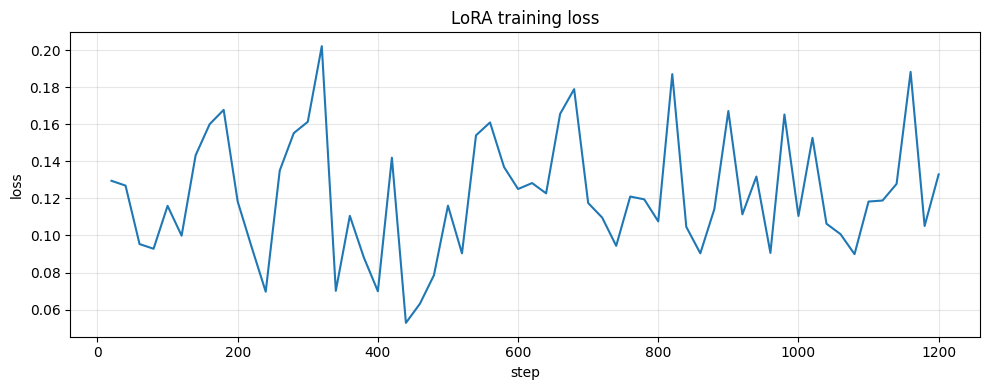

In [8]:
if Path(history_path).exists():
    df = pd.read_csv(history_path)
    plt.figure(figsize=(10, 4))
    plt.plot(df['step'], df['loss'])
    plt.xlabel('step'); plt.ylabel('loss'); plt.title('LoRA training loss')
    plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 5. Сборка пайплайна для инференса

In [9]:
del unet
torch.cuda.empty_cache()

pipe = StableDiffusionPipeline.from_pretrained(BASE_MODEL, torch_dtype=torch.float16, safety_checker=None, requires_safety_checker=False)
pipe = pipe.to(device)
pipe.set_progress_bar_config(disable=True)

from peft import LoraConfig as PeftLoraConfig
from peft.utils import set_peft_model_state_dict
from safetensors.torch import load_file

lora_cfg_inf = PeftLoraConfig(
    r=LORA_RANK, lora_alpha=LORA_RANK,
    target_modules=['to_q', 'to_k', 'to_v', 'to_out.0'],
    lora_dropout=0.0, bias='none',
)
pipe.unet = get_peft_model(pipe.unet, lora_cfg_inf)
lora_sd = load_file(str(lora_state_path))
missing, unexpected = pipe.unet.load_state_dict(lora_sd, strict=False)
print(f'loaded LoRA: missing keys={len(missing)} unexpected={len(unexpected)}')
pipe.unet = pipe.unet.to(device, dtype=torch.float16)
pipe.unet.eval()
print('pipeline ready')

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

loaded LoRA: missing keys=686 unexpected=0
pipeline ready


## 6. Генерация в разных стилях (1 качественное + 5 ещё)

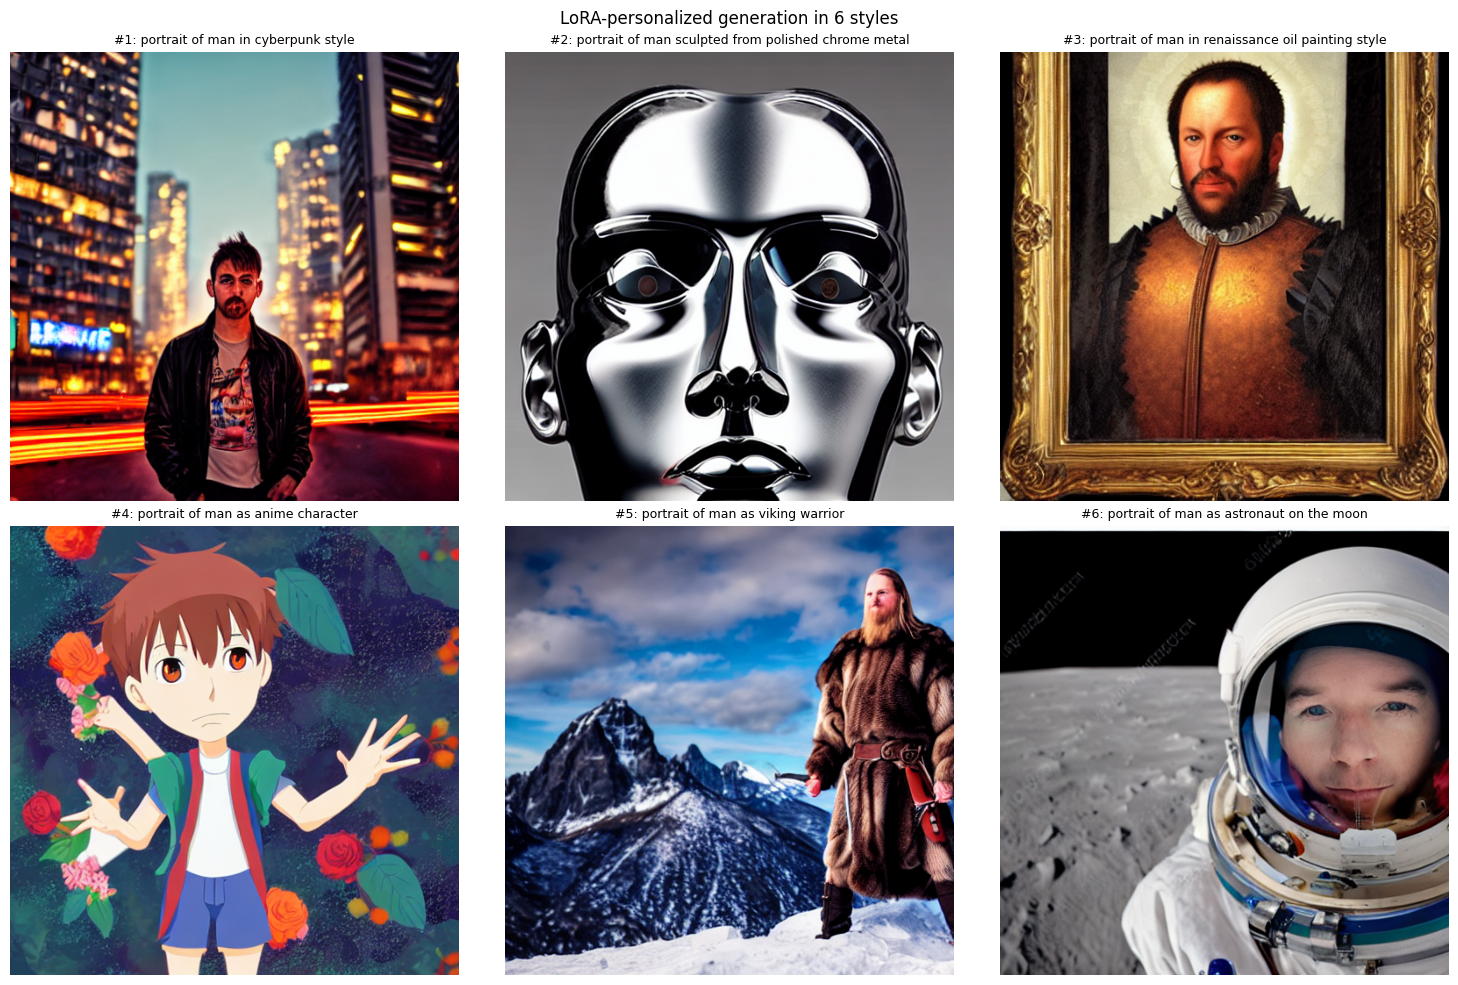

In [10]:
STYLE_PROMPTS = [
    f'portrait of {INSTANCE_TOKEN} {GENDER} in cyberpunk style, neon lights, futuristic city, glowing reflections, ultra detailed, 8k, cinematic lighting',
    f'portrait of {INSTANCE_TOKEN} {GENDER} sculpted from polished chrome metal, reflective surface, studio lighting',
    f'portrait of {INSTANCE_TOKEN} {GENDER} in renaissance oil painting style, baroque background, dramatic lighting',
    f'portrait of {INSTANCE_TOKEN} {GENDER} as anime character, studio ghibli style, vibrant colors',
    f'portrait of {INSTANCE_TOKEN} {GENDER} as viking warrior, snowy mountain background, fur cloak, epic fantasy',
    f'portrait of {INSTANCE_TOKEN} {GENDER} as astronaut on the moon, helmet visor reflecting earth, space photography',
]

style_results = []
g = torch.Generator(device=device).manual_seed(SEED)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, prompt in enumerate(STYLE_PROMPTS):
    out = pipe(prompt, num_inference_steps=INFERENCE_STEPS, guidance_scale=GUIDANCE, generator=g).images[0]
    out_path = SAMPLES_DIR / f'style_{i+1:02d}.png'
    out.save(out_path)
    style_results.append({'index': i+1, 'prompt': prompt, 'file': str(out_path)})
    ax = axes[i//3, i%3]
    ax.imshow(out); ax.axis('off')
    short = prompt.split(',')[0].replace(f'{INSTANCE_TOKEN} ', '')
    ax.set_title(f'#{i+1}: {short}', fontsize=9)
plt.suptitle('LoRA-personalized generation in 6 styles')
plt.tight_layout(); plt.show()

## 7. Лучший выбор — крупно

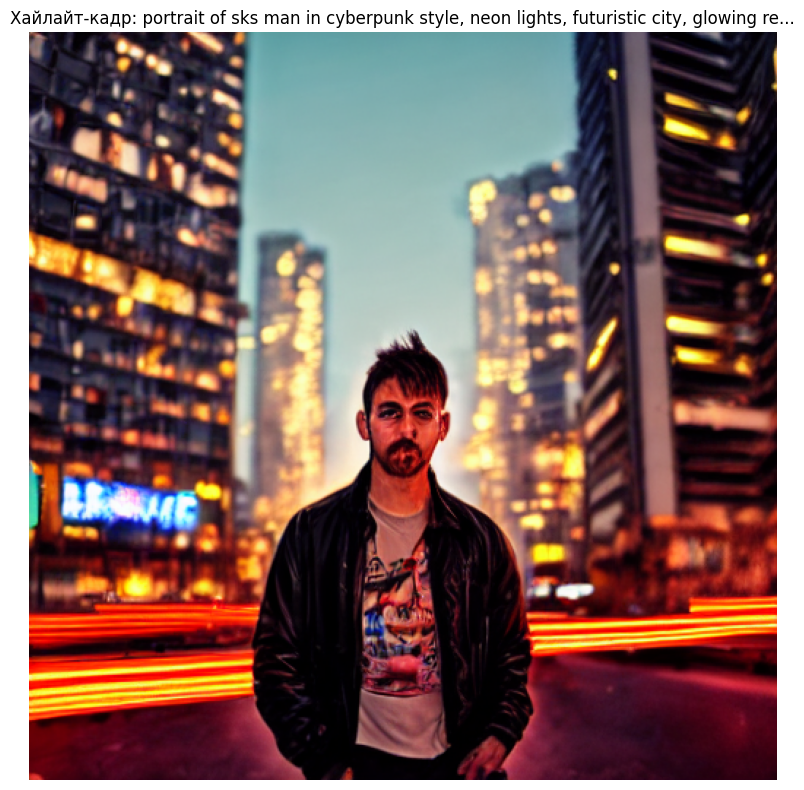

In [11]:
best = Image.open(SAMPLES_DIR / 'style_01.png')
plt.figure(figsize=(8, 8))
plt.imshow(best); plt.axis('off')
plt.title(f'Хайлайт-кадр: {STYLE_PROMPTS[0][:80]}...')
plt.tight_layout(); plt.show()

## 8. forest / city / beach

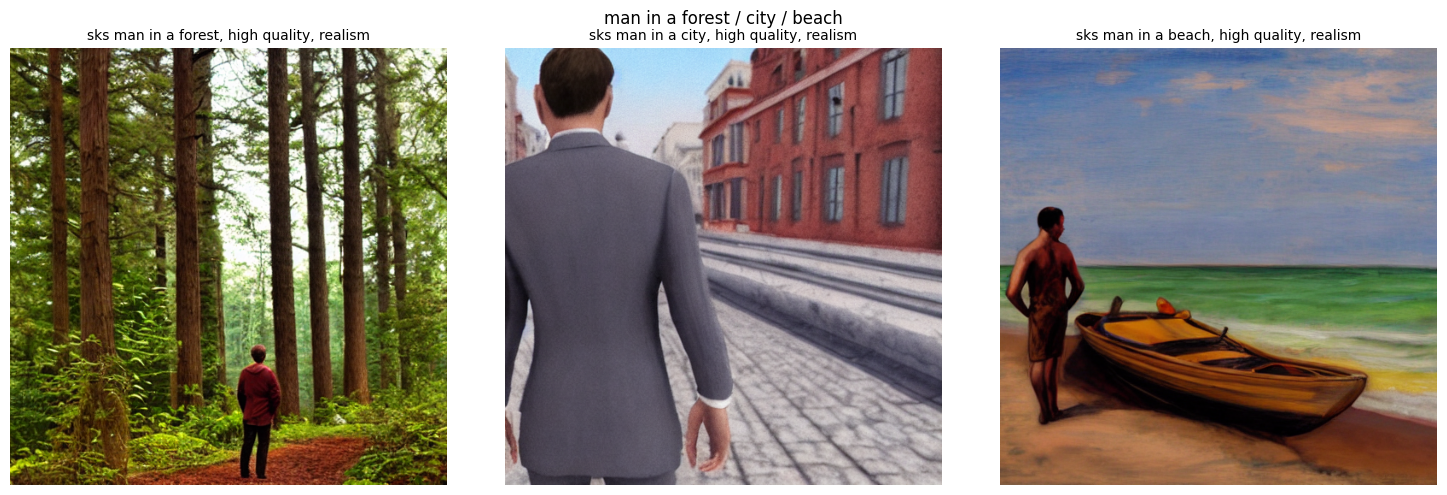

In [12]:
ENV_PROMPTS = [
    f'{INSTANCE_TOKEN} {GENDER} in a forest, high quality, realism',
    f'{INSTANCE_TOKEN} {GENDER} in a city, high quality, realism',
    f'{INSTANCE_TOKEN} {GENDER} in a beach, high quality, realism',
]

env_results = []
g = torch.Generator(device=device).manual_seed(SEED + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, prompt in enumerate(ENV_PROMPTS):
    out = pipe(prompt, num_inference_steps=INFERENCE_STEPS, guidance_scale=GUIDANCE, generator=g).images[0]
    out_path = SAMPLES_DIR / f'env_{i+1:02d}.png'
    out.save(out_path)
    env_results.append({'index': i+1, 'prompt': prompt, 'file': str(out_path)})
    axes[i].imshow(out); axes[i].axis('off')
    axes[i].set_title(prompt, fontsize=10)
plt.suptitle(f'{GENDER} in a forest / city / beach')
plt.tight_layout(); plt.show()

## 9. results.json

In [13]:
results = {
    'task': 'personalized_text_to_image_StableDiffusion',
    'base_model': BASE_MODEL,
    'method': 'LoRA fine-tuning (peft) on user photos with DreamBooth-style instance prompt',
    'instance_token': INSTANCE_TOKEN,
    'gender': GENDER,
    'instance_prompt': INSTANCE_PROMPT,
    'lora': {
        'rank': LORA_RANK,
        'target_modules': ['to_q', 'to_k', 'to_v', 'to_out.0'],
        'optimizer': 'AdamW8bit (bitsandbytes)',
        'lr': LR,
        'max_train_steps': MAX_TRAIN_STEPS,
        'grad_accum': GRAD_ACCUM,
        'batch_size': BATCH,
    },
    'inference': {
        'resolution': RESOLUTION,
        'num_inference_steps': INFERENCE_STEPS,
        'guidance_scale': GUIDANCE,
        'negative_prompt': None,
        'use_img2img': False,
    },
    'reference_photos': [p.name for p in me_imgs],
    'style_outputs': style_results,
    'env_outputs': env_results,
}
RESULTS_PATH.write_text(json.dumps(results, indent=2, ensure_ascii=False))
print(json.dumps({k: results[k] for k in ['base_model', 'method', 'instance_prompt', 'lora', 'inference']}, indent=2, ensure_ascii=False))

{
  "base_model": "runwayml/stable-diffusion-v1-5",
  "method": "LoRA fine-tuning (peft) on user photos with DreamBooth-style instance prompt",
  "instance_prompt": "a photo of sks man",
  "lora": {
    "rank": 16,
    "target_modules": [
      "to_q",
      "to_k",
      "to_v",
      "to_out.0"
    ],
    "optimizer": "AdamW8bit (bitsandbytes)",
    "lr": 0.0001,
    "max_train_steps": 1200,
    "grad_accum": 2,
    "batch_size": 1
  },
  "inference": {
    "resolution": 512,
    "num_inference_steps": 30,
    "guidance_scale": 7.5,
    "negative_prompt": null,
    "use_img2img": false
  }
}
